# **Assignment 3: Data Analysis - Thyroid Study Group**

**Group Members:** Jiabei (Leader: Blake) Wei, Esmeralda Castillo Medina, Andrew Crisologo, Aria Takeuchi  
**Date:** 3/24/2026

## Purpose
This notebook presents our final group analysis of the thyroid-related datasets. We imported the extracted data into Python, cleaned and transformed the datasets, and performed descriptive and exploratory analyses to generate insights relevant to health informatics decision-making.

## Files Used
- `ss_visits_thyroid_clean.csv`
- `ss_measurements_timeseries.csv`

## Analytic Questions
1. **What visit types are most common for thyroid-related care, and are certain thyroid diagnoses more likely to appear in specific visit types?**
2. **What factors influence length of stay for inpatient thyroid-related visits?**
3. **How do the demographic profiles of the thyroid visit cohort compare with the demographic profiles of patients who received TSH, T3, or T4 testing, and do these patterns align with expected real-world thyroid care trends?**

## Team Process Summary
- Blake cleaned and prepared the two source files for analysis.
- Esme focused on Question 1.
- Andrew focused on Question 2.
- Aira focused on Question 3 and everybody reviewed. 
- Blake reviewed and integrated the results for final write-up.


# **Part 1. Data Cleaning and Preparation Summary**

Please find `assignment3_data_cleaning.py` script. 

## Data Cleaning Script Summary

- Cleans two original source files: `ss_visits_thyroid_clean.csv` and `ss_measurements_timeseries.csv`
- Produces four cleaned outputs: `visits_analysis_ready.csv`, `measurements_analysis_ready.csv`, `thyroid_testing_cohort.csv`, and `cleaning_summary.txt`

### Visit dataset cleaning
- Standardizes text fields and converts placeholder values such as `"nan"`, `"None"`, and empty strings to missing values
- Parses `visit_start_date` and `visit_end_date` as datetime variables
- Converts `year_of_birth` to numeric and sets invalid years outside `1900`–`2026` to missing
- Creates `age_at_visit` from visit year and `year_of_birth`
- Sets impossible `age_at_visit` values below `0` or above `120` to missing
- Creates age categories in `age_group`: `0-17`, `18-34`, `35-49`, `50-64`, and `65+`
- Calculates `visit_duration_days` from `visit_end_date - visit_start_date`
- Sets negative `visit_duration_days` values to missing
- Creates visit duration flags: `same_day_visit_flag`, `long_visit_flag_7d`, and `long_visit_flag_30d`
- Standardizes visit setting categories into `visit_type_grouped`: `Office/Outpatient`, `Inpatient-Related`, `Emergency-Related`, `Telehealth`, `Case Management`, and `Other`
- Creates cleaned categorical fields: `gender_clean`, `race_clean`, `ethnicity_clean`, `condition_description_clean`, and `visit_type_clean`
- Creates helper indicator flags: `office_related_flag`, `inpatient_related_flag`, `emergency_related_flag`, and `telehealth_flag`

### Measurement dataset cleaning
- Parses `measurement_date` as datetime
- Converts numeric clinical fields to numeric values, including `weight`, `bmi`, `triglycerides`, `hba1c`, `glucose`, `ast`, `alt`, `creatinine`, `albumin`, `tsh`, `t3`, and `t4`
- Treats sentinel value `-9999999` as missing
- Maps coded demographic values into readable categories for `gender_clean`, `race_clean`, and `ethnicity_clean`
- Converts `year_of_birth` to numeric and sets invalid years outside `1900`–`2026` to missing
- Creates `age_at_measurement`
- Creates `age_group`: `0-17`, `18-34`, `35-49`, `50-64`, and `65+`
- Adds time helper fields `measurement_year` and `measurement_month`
- Creates thyroid testing flags: `has_tsh`, `has_t3`, `has_t4`, and `has_any_thyroid_test`
- Sets impossible negative measurement values to missing where appropriate

### Thyroid testing cohort creation
- Filters to patients with at least one thyroid-related lab result using `has_any_thyroid_test`
- Sorts records by patient and date
- Keeps the earliest thyroid test record per patient
- Saves the resulting person-level testing cohort as `thyroid_testing_cohort.csv`

### Documentation output
- Writes `cleaning_summary.txt` to document row counts, unique patients, valid ages, visit durations, and thyroid testing counts
- Records key cleaning rules such as invalid `year_of_birth` handling, negative duration handling, and sentinel missing-value replacement

### Methodological note
- All analyses in the final notebook use cleaned data only
- The visits and measurements datasets were cleaned separately and were not force-joined into an unsupported patient-level merged file


# **Part 2. Question 1**
## What visit types are most common for thyroid-related care, and are certain thyroid diagnoses more likely to appear in specific visit types?

### **Step 1. Importing the Required Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Import and verify required csv files
visits_thyroid = pd.read_csv("visits_analysis_ready.csv")
visits_thyroid.head()

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


In [ ]:
# Verify columns
visits_thyroid.columns

Index(['person_id', 'gender_concept_id', 'gender', 'gender_clean',
       'year_of_birth', 'age_at_visit', 'age_group', 'race', 'race_clean',
       'ethnicity', 'ethnicity_clean', 'snomed_condition_concept_id',
       'condition_description', 'condition_description_clean',
       'visit_concept_id', 'visit_type', 'visit_type_clean',
       'visit_type_group', 'visit_start_date', 'visit_end_date',
       'visit_duration_days', 'same_day_visit_flag', 'long_visit_flag_7d',
       'long_visit_flag_30d', 'office_related_flag', 'inpatient_related_flag',
       'emergency_related_flag', 'telehealth_flag'],
      dtype='str')

In [ ]:
# Verify length of data
len(visits_thyroid)

179124

### **Step 2. Question 1A: What visit types are most common for thyroid-related care?**
- This script provides which `visit type` are the most common from the thyroid population by obtaining the total counts for each `visit type`
- We will create a frequency table where we have 3 main columns: `Visit Type`, `Count`, and `Percent` (rounded by 2 decimals)

In [ ]:
# Displays total visit type count for all thyroid-related cases in a frequency table into 2 main columns: Visit Type & Count
visit_type_count = visits_thyroid["visit_type_group"].str.lower().str.strip().value_counts()

visit_type_table = visit_type_count.reset_index()
visit_type_table.columns = ["Visit Type", "Count"]

# Displays the Visit Type Frequency Table by converting the data into percentages rounded by 2 decimals
# Adds a "percent" column to display percentages for each visit type

visit_type_table["Percent"] = (visit_type_table["Count"] / visit_type_table["Count"].sum() * 100).round(2)
visit_type_table["Percent"] = visit_type_table["Percent"].astype(str) + "%"

visit_type_table["Visit Type"] = visit_type_table["Visit Type"].str.title()

visit_type_table

,Visit Type,Count,Percent
0,Office/Outpatient,132319,73.87%
1,Emergency-Related,23120,12.91%
2,Inpatient-Related,11533,6.44%
3,Telehealth,6117,3.41%
4,Case Management,6035,3.37%


### Visual 1: Most Common Visit Types for Thyroid-Related Care Bar Graph
- We used matplotlib to plot the desired data
- We'll plot a bar graph to display the most common `visit types` for thyroid-related care

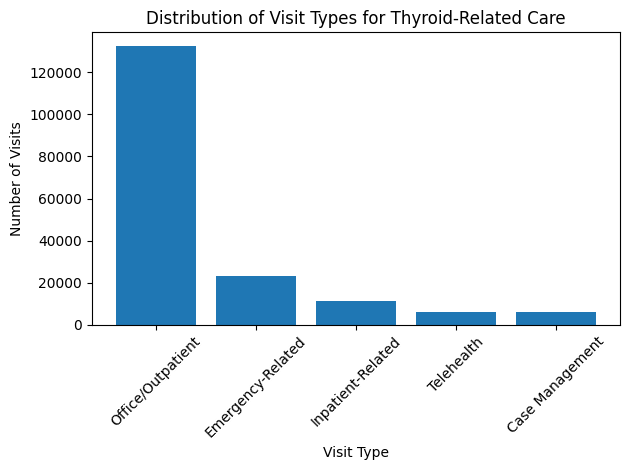

In [ ]:
# Creates a Bar Graph to display results
plt.bar(visit_type_table["Visit Type"], visit_type_table["Count"])

plt.title("Distribution of Visit Types for Thyroid-Related Care")
plt.xlabel("Visit Type")
plt.ylabel("Number of Visits")

plt.xticks(rotation = 45)
plt.tight_layout()

# Saves the figure as a png
plt.savefig("visit_type_bar.png")
plt.show()

### **Narrative for Question 1A: What visit types are most common for thyroid-related care?**

### Objective:
- Find which visit types are most common for our thyroid-related patient population

### CSV files used:
- Used 1 csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Figure out the total counts for each visit type
2. Convert the obtained data into a frequency table that includes:
    - 3 main columns: `Visit Type`, `Count`, and `Percent` (rounded by 2 decimals)
3. Create a bar graph to visualize overall results

### Findings:
After figuring out the total number of thyroid-related patient cases per visit type, we discovered that there are 5 main visit types:
1. office/outpatient
2. emergency-related
3. inpatient-related
4. telehealth
5. case management

From these 5 visit types, we can conclude that the "office/outpatient" visit type is where most cases are seen for thyroid-related care with a total of 132,319 cases (74%)! While, "emergency-related" care make up 13% of total visit types. Essentially, the top 3 most common visit types for thyroid-related care are:
1. office/outpatient (132,319 total or 73.87%)
2. emergency-related (23,120 total or 12.91%)
3. inpatient-related (11,533 total or 6.44%)

Overall, we can conclude that the most common visit type for thyroid-related care are "office/outpatient" visits that make up a total of 74% of visits.

### **Step 3. Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**
### Creating a Contingency Table
- This script provides information on the frequency of each `thyroid-related diagnosis` in each `visit type`
- We will be creating a contingency table with our 2 categorical variables involved that are:
    1. Our **"column"** variable = Visit Type = `visit_type_group_column`
    2. Our **"row"**  variable = Thyroid Diagnosis = `condition_description_clean`

In [ ]:
# Create a contingency table with percentages 
diagnosis_by_visit_type_percent = pd.crosstab(
    visits_thyroid["condition_description_clean"],
    visits_thyroid["visit_type_group"],
    normalize = "index"
) * 100

# Add column and row labels
percent_contingency_table = diagnosis_by_visit_type_percent.round(2)
percent_contingency_table.index.name = "Thyroid Diagnosis"
percent_contingency_table.columns.name = "Visit Type"

# Adds '%' at the end of the values
percent_contingency_table_display = percent_contingency_table.astype(str) + "%"

print(percent_contingency_table_display)


Visit Type                Case Management Emergency-Related Inpatient-Related  \
Thyroid Diagnosis                                                               
Disorder of thyroid gland           1.27%             6.66%             2.64%   
Hyperthyroidism                     6.96%             7.93%             3.01%   
Hypothyroidism                      3.21%            13.39%             6.76%   

Visit Type                Office/Outpatient Telehealth  
Thyroid Diagnosis                                       
Disorder of thyroid gland            86.58%      2.85%  
Hyperthyroidism                      74.66%      7.44%  
Hypothyroidism                       73.45%      3.19%  


### Visual 2: Visit Type Distribution by Thyroid Diagnosis Heatmap
- We'll plot a heatmap to display the visit type distributions by thyroid diagnosis

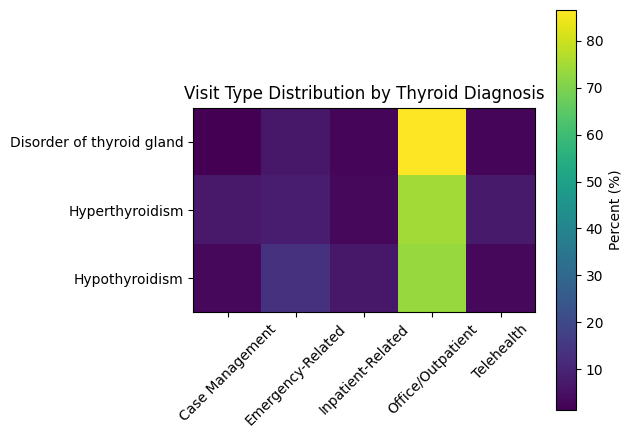

In [ ]:
# Create a Heatmap to display results
plt.imshow(percent_contingency_table, aspect = 'equal')
plt.colorbar(label = "Percent (%)")

plt.xticks(
    range(len(percent_contingency_table.columns)),
    percent_contingency_table_display.columns,
    rotation = 45
)

plt.yticks(
    range(len(percent_contingency_table.index)),
    percent_contingency_table_display.index
)

plt.title("Visit Type Distribution by Thyroid Diagnosis")

plt.tight_layout()
plt.show()

### Visual 3: Visit Type Distribution by Thyroid Diagnosis Bar Graph
- We used matplotlib to plot a bar graph to display the visit type distribution by thyroid diagnosis

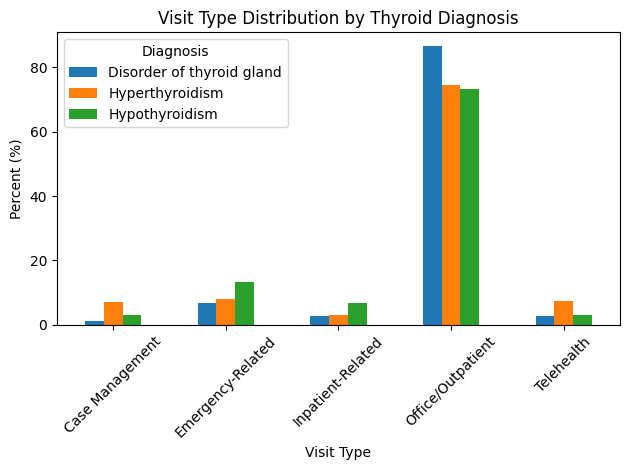

In [ ]:
# Create a bar graph
percent_contingency_table.T.plot(kind = "bar")

plt.title("Visit Type Distribution by Thyroid Diagnosis")
plt.xlabel("Visit Type")
plt.ylabel("Percent (%)")

plt.xticks(rotation = 45)
plt.legend(title = "Diagnosis")

plt.tight_layout()
plt.show()

### **Narrative for Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**

### Objective:
- Find if there's specific thyroid diagnosis that are more likely to appear in specific visit types than others

### CSV files used:
- Used 1 csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Create a contingency table to figure out the frequency of each thyroid-related diagnosis in each visit type
    - Will provide the percent distribution of thyroid diagnosis across the various visit types
2. Create a Heatmap and a Bar Graph to properly visualize our findings

### Findings:

After creating a contingency table, we can see that a large portion of thyroid-related cases make up the "office/outpatient" visit type. The diagnosis for "Disorder of the Thyroid Gland" make up 87% of the "office/outpatient" visits. While, "Hyperthyroidism" and "Hypothyroidism" both have a similar frequency rates of 74% in the same visit type. In addition, the "emergency-related" visits have a 13% rate of "Hypothyroidism" diagnosis compared to the other visit types. 

These results are further validated in both the visit type distribution by thyroid diagnosis heatmap and bar graph. We can see that a large percent of thyroid diagnosis are made in "office/outpatient" care settings (which is displayed by a bright yellow color), and the most common diagnosis in this care setting is the "Disorder of the Thyroid Gland". However, as stated before, both "Hyperthyroidism" and "Hypothyroidism" still have abnormally elevated percentages in the same care setting (the lower percent areas are those displayed in darker purple colors).

The heatmap and bar graph suggests that most thyroid-related care happens more often in office/outpatient visits, which can indicate that the diagnosis is frequently managed in this visit type. This can be due to the fact that most thyroid conditions are chronic but manageable if one is consistent with their treatment plans. Therefore, most thryoid-related care is not commonly diagnosed or treated in emergency and hospitilization related care. There is a slightly elevated percentage of hypothyroidism diagnosis that are seen in emergency-related settings and hyperthyroidism in telehealth. However, the percentage of these care settings are not as extremely pronounced as those seen in the office/outpatient care setting.


### Limitations

First, it was conducted at the visit level rather than the patient level, so patients with multiple visits may be represented more than once. Second, diagnosis and visit type categories depend on the quality and consistency of source coding, so some misclassification may remain even after cleaning. Third, the analysis is descriptive and does not test causality, so observed differences in visit-type patterns across diagnoses should be interpreted as associations rather than evidence that a diagnosis causes a specific care setting. Finally, the dataset does not include additional clinical context such as disease severity, symptoms, or referral reason, which may also influence where care occurs.

# **Part 3. Question 2**
## What factors influence length of stay for inpatient thyroid-related visits?

### **Step 1:**

**Question:** Among patients with thyroid conditions who had inpatient or agency visits, do length-of-stay (LOS) patterns differ by condition, visit type, gender, race, or age group, and what factors are associated with longer stays?

**Data Source:** `visits_analysis_ready.csv` — pre-cleaned via `assignment3_data_cleaning.py` from the original `ss_visits_thyroid_clean.csv` (SubSalt data).

**Key Data Dictionary Note:** Per the D2L announcement, `visit_end_date` is only applicable for inpatient and agency visits. LOS is therefore computed exclusively for those encounter types. All other visit types use `visit_start_date` only.

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Display and plot settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Load only the visits dataset (pre-cleaned)
visits = pd.read_csv("visits_analysis_ready.csv")

print(f"Visits dataset: {visits.shape[0]:,} rows x {visits.shape[1]} columns")
print(f"Unique patients: {visits['person_id'].nunique():,}")
print(f"Memory usage: {visits.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Visits dataset: 179,124 rows x 28 columns
Unique patients: 32,231
Memory usage: 171.6 MB


### **Step 2. Filter to Inpatient/Agency Visits**

The data dictionary states that `visit_end_date` is only meaningful for inpatient and home health visit types. Applying length of stay (LOS) calculations to office or outpatient visits would produce misleading results.

Age groups were converted into clinical decades (18–29, 30–39, ... 80+) since these are standard groupings in the medical literature.

In [ ]:
# 2a. Filter to visit types where LOS is valid
# Per data dictionary: visit_end_date applies to inpatient and agency visits only
los_valid_types = [
    "Inpatient Visit",
    "Inpatient Hospital",
    "Emergency Room and Inpatient Visit",
    "Case Management Agency",
]

inp = visits[visits["visit_type"].isin(los_valid_types)].copy()
print(f"Rows with valid LOS (inpatient + agency): {len(inp):,}")
print(f"Unique patients: {inp['person_id'].nunique():,}")
print(f"\nVisit type breakdown:")
print(inp["visit_type"].value_counts().to_string())

Rows with valid LOS (inpatient + agency): 38,049
Unique patients: 12,580

Visit type breakdown:
visit_type
Emergency Room and Inpatient Visit    20481
Inpatient Visit                       11309
Case Management Agency                 6035
Inpatient Hospital                      224


In [ ]:
# 2b. Rename LOS column for clarity and handle edge cases
inp.rename(columns={"visit_duration_days": "los_days"}, inplace=True)

# Delete rows where LOS is missing or negative
before = len(inp)
inp = inp[inp["los_days"].notna() & (inp["los_days"] >= 0)].copy()
print(f"Dropped {before - len(inp)} rows with missing/invalid LOS")

# 2c. Convert to clinical decade groups
# Standard clinical grouping used in the literature
inp["age_decade"] = pd.cut(
    inp["age_at_visit"],
    bins=[17, 29, 39, 49, 59, 69, 79, 120],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"],
    right=True,
)

print(f"\nAge decade distribution:")
print(inp["age_decade"].value_counts().sort_index().to_string())
print(f"\nMissing age (excluded from age-based analyses): {inp['age_decade'].isna().sum()}")

Dropped 0 rows with missing/invalid LOS

Age decade distribution:
age_decade
18-29     1167
30-39     2398
40-49     3252
50-59     5387
60-69     8290
70-79    10208
80+       7236

Missing age (excluded from age-based analyses): 111


In [ ]:
# 2d. Create a simplified visit subtype for cleaner labels
# "Emergency Room and Inpatient Visit" is long; shorten for plot labels
visit_label_map = {
    "Inpatient Visit": "Inpatient",
    "Inpatient Hospital": "Inpatient Hospital",
    "Emergency Room and Inpatient Visit": "ER-to-Inpatient",
    "Case Management Agency": "Case Mgmt/Agency",
}
inp["visit_subtype"] = inp["visit_type"].map(visit_label_map)

# Summary of the analytic dataset
print(f"Final analytic dataset: {len(inp):,} rows, {inp['person_id'].nunique():,} unique patients")
print(f"\nLOS summary (days):")
print(inp["los_days"].describe().round(1).to_string())

Final analytic dataset: 38,049 rows, 12,580 unique patients

LOS summary (days):
count    38049.0
mean        53.6
std         50.1
min          0.0
25%         20.0
50%         47.0
75%         67.0
max        398.0


### **Step 3. Descriptive Statistics**

Descriptives were run first to get a sense for the data before interpreting results, and can expose remaining data quality issues.

In [ ]:
# 3a. Table 1: LOS summary by key grouping variables
# Build a summary function to reuse
def los_summary_by_group(data, group_col, label=None):
    """Return a summary DataFrame of LOS stats grouped by a column."""
    summary = (
        data.groupby(group_col, observed=True)["los_days"]
        .agg(["count", "mean", "median", "std", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
        .round(1)
    )
    summary.columns = ["N", "Mean", "Median", "SD", "Q1", "Q3"]
    summary.index.name = label or group_col
    return summary

# LOS by visit subtype
print("=" * 65)
print("LOS (Days) by Visit Subtype")
print("=" * 65)
display(los_summary_by_group(inp, "visit_subtype", "Visit Subtype"))

# LOS by condition
print("\n" + "=" * 65)
print("LOS (Days) by Thyroid Condition")
print("=" * 65)
display(los_summary_by_group(inp, "condition_description_clean", "Condition"))

LOS (Days) by Visit Subtype


,N,Mean,Median,SD,Q1,Q3
Visit Subtype,,,,,,
Case Mgmt/Agency,6035,54.2,57.0,45.1,21.0,64.0
ER-to-Inpatient,20481,54.1,46.0,52.0,21.0,68.0
Inpatient,11309,52.2,45.0,48.9,19.0,67.0
Inpatient Hospital,224,61.3,56.0,54.7,30.8,73.0



LOS (Days) by Thyroid Condition


,N,Mean,Median,SD,Q1,Q3
Condition,,,,,,
Disorder of thyroid gland,365,51.6,42.0,51.3,21.0,64.0
Hyperthyroidism,1732,53.2,46.5,47.8,19.0,66.0
Hypothyroidism,35952,53.6,47.0,50.2,21.0,67.0


In [ ]:
# 3b. LOS by demographics
# Gender
print("=" * 65)
print("LOS (Days) by Gender")
print("=" * 65)
display(los_summary_by_group(inp, "gender_clean", "Gender"))

# Race
print("\n" + "=" * 65)
print("LOS (Days) by Race")
print("=" * 65)
display(los_summary_by_group(inp, "race_clean", "Race"))

# Ethnicity
print("\n" + "=" * 65)
print("LOS (Days) by Ethnicity")
print("=" * 65)
display(los_summary_by_group(inp, "ethnicity_clean", "Ethnicity"))

# Age decade
print("\n" + "=" * 65)
print("LOS (Days) by Age Decade")
print("=" * 65)
display(los_summary_by_group(inp.dropna(subset=["age_decade"]), "age_decade", "Age Decade"))

LOS (Days) by Gender


,N,Mean,Median,SD,Q1,Q3
Gender,,,,,,
F,26018,53.2,47.0,48.8,20.0,67.0
M,12028,54.5,46.0,52.8,21.0,68.0
Other/Unknown,3,35.0,36.0,3.6,33.5,37.0



LOS (Days) by Race


,N,Mean,Median,SD,Q1,Q3
Race,,,,,,
American Indian or Alaska Native,625,54.5,46.0,52.0,20.0,67.0
Asian,1269,53.8,46.0,51.8,19.0,68.0
Black or African American,4611,54.2,47.0,51.6,21.0,66.5
Native Hawaiian or Other Pacific Islander,87,45.4,40.0,35.4,18.0,63.0
Other,5156,52.9,46.0,47.5,20.0,67.0
White,26301,53.6,47.0,50.3,20.0,67.0



LOS (Days) by Ethnicity


,N,Mean,Median,SD,Q1,Q3
Ethnicity,,,,,,
Hispanic or Latino,5844,54.1,46.0,52.0,21.0,67.0
Not Hispanic or Latino,29439,53.7,47.0,50.1,20.0,67.0
Other,2766,51.1,45.0,45.6,20.0,65.0



LOS (Days) by Age Decade


,N,Mean,Median,SD,Q1,Q3
Age Decade,,,,,,
18-29,1167,53.1,47.0,47.9,20.0,67.0
30-39,2398,53.8,47.0,49.3,21.0,66.0
40-49,3252,53.0,46.0,49.5,21.0,66.0
50-59,5387,53.7,46.0,50.7,21.0,66.0
60-69,8290,52.9,46.0,48.9,20.0,67.0
70-79,10208,53.6,47.0,49.7,20.0,67.0
80+,7236,54.6,48.0,52.7,20.0,68.0


### **Step 4. Figures**

For comparing distributions of a continuous variable (LOS) across categories, box plots can show medians, interquartile ranges, and outliers. Bar charts are helpful for counts. Heat maps can help provide a visual representation of relationships between two categorical variables.

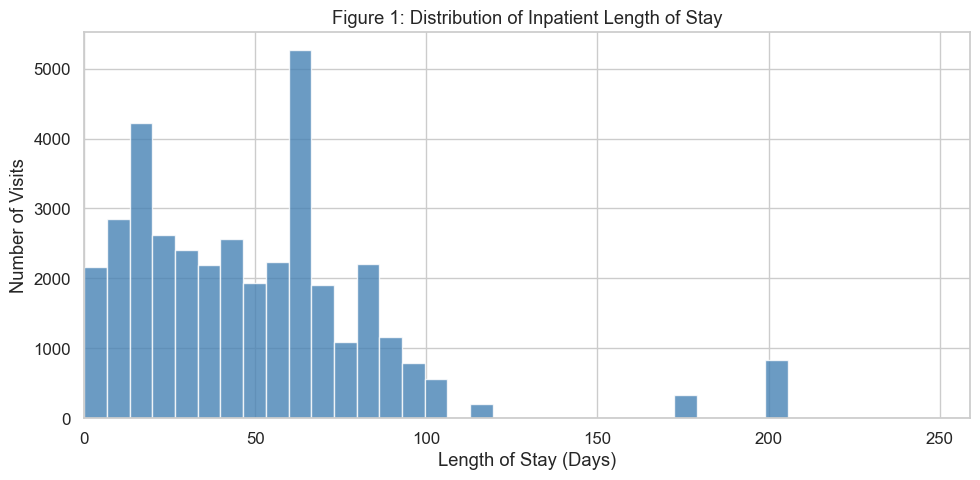

In [ ]:
# ── Figure 1: Overall LOS Distribution ──────────────────────────────
# A histogram shows the shape of the LOS distribution.
# This is always the first figure in a LOS analysis: understand the
# overall distribution (normal, non-parametric) before stratifying.

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(inp["los_days"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Length of Stay (Days)")
ax.set_ylabel("Number of Visits")
ax.set_title("Figure 1: Distribution of Inpatient Length of Stay")
ax.set_xlim(0, inp["los_days"].quantile(0.99))  # Trim extreme outliers for readability
plt.tight_layout()
plt.show()

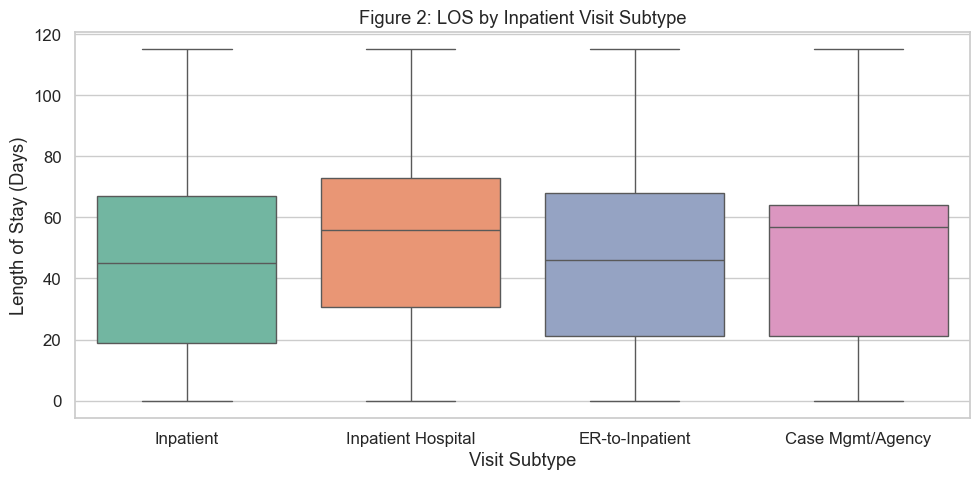

In [ ]:
# ── Figure 2: LOS by Visit Subtype (Box Plot) ──────────────────────
# Each box shows the median (line), IQR (box), and outliers (dots).

fig, ax = plt.subplots(figsize=(10, 5))
order = ["Inpatient", "Inpatient Hospital", "ER-to-Inpatient", "Case Mgmt/Agency"]
sns.boxplot(
    data=inp, x="visit_subtype", y="los_days", order=order,
    palette="Set2", showfliers=False, ax=ax,
)
ax.set_xlabel("Visit Subtype")
ax.set_ylabel("Length of Stay (Days)")
ax.set_title("Figure 2: LOS by Inpatient Visit Subtype")
plt.tight_layout()
plt.show()

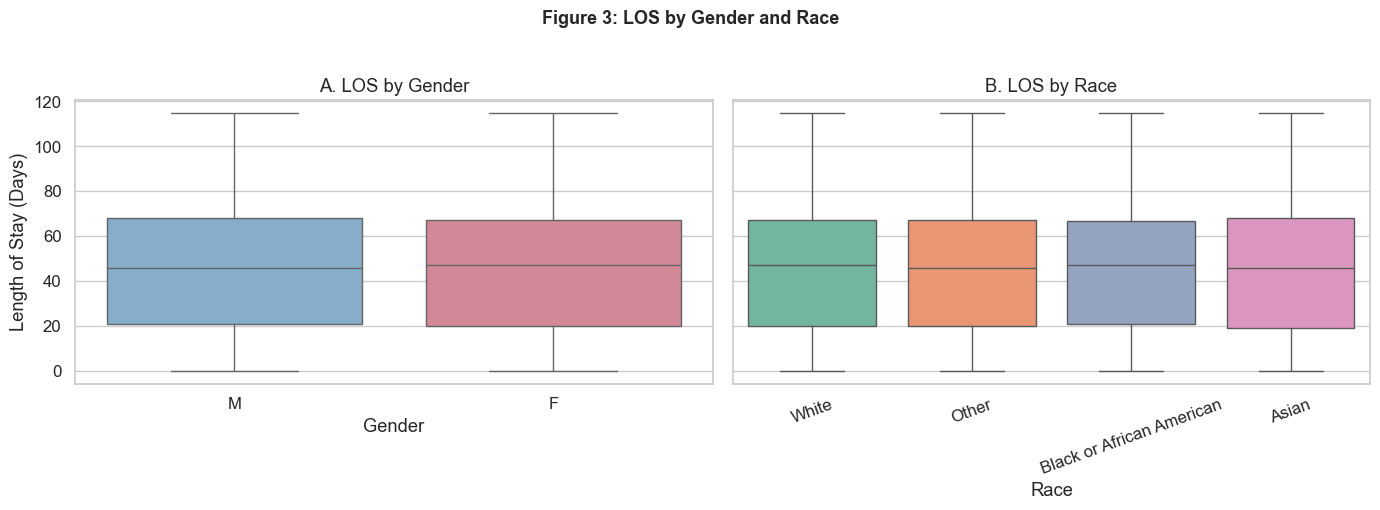

In [ ]:
# Figure 3: LOS by Gender and Race (Grouped Box Plots)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Panel A: Gender
sns.boxplot(
    data=inp[inp["gender_clean"].isin(["F", "M"])],
    x="gender_clean", y="los_days",
    palette={"F": "#e07b91", "M": "#7bafd4"}, showfliers=False, ax=axes[0],
)
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Length of Stay (Days)")
axes[0].set_title("A. LOS by Gender")

# Panel B: Race (top 4 groups for readability)
top_races = inp["race_clean"].value_counts().head(4).index.tolist()
sns.boxplot(
    data=inp[inp["race_clean"].isin(top_races)],
    x="race_clean", y="los_days", order=top_races,
    palette="Set2", showfliers=False, ax=axes[1],
)
axes[1].set_xlabel("Race")
axes[1].set_ylabel("")
axes[1].set_title("B. LOS by Race")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Figure 3: LOS by Gender and Race", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

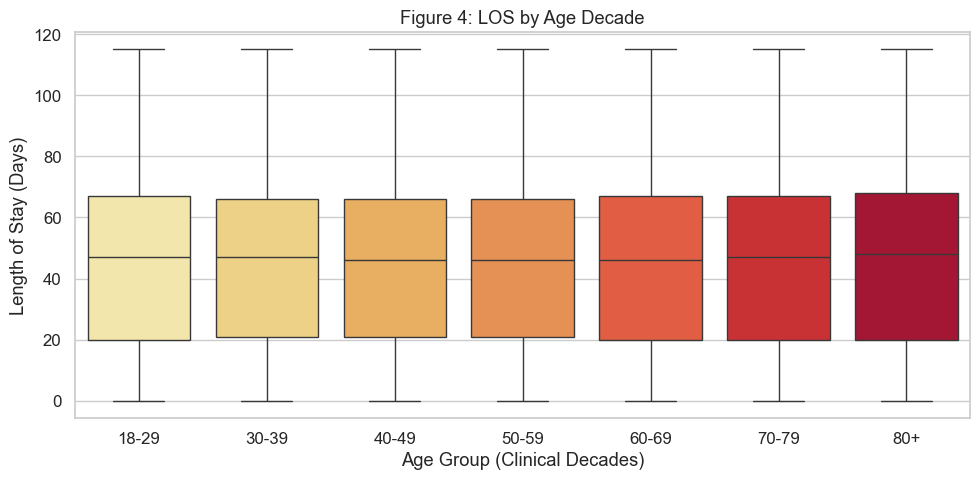

In [ ]:
# ── Figure 4: LOS by Age Decade ─────────────────────────────────────
# Clinical decade groupings more closely match reported medical literature.

age_data = inp.dropna(subset=["age_decade"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=age_data, x="age_decade", y="los_days",
    palette="YlOrRd", showfliers=False, ax=ax,
)
ax.set_xlabel("Age Group (Clinical Decades)")
ax.set_ylabel("Length of Stay (Days)")
ax.set_title("Figure 4: LOS by Age Decade")
plt.tight_layout()
plt.show()

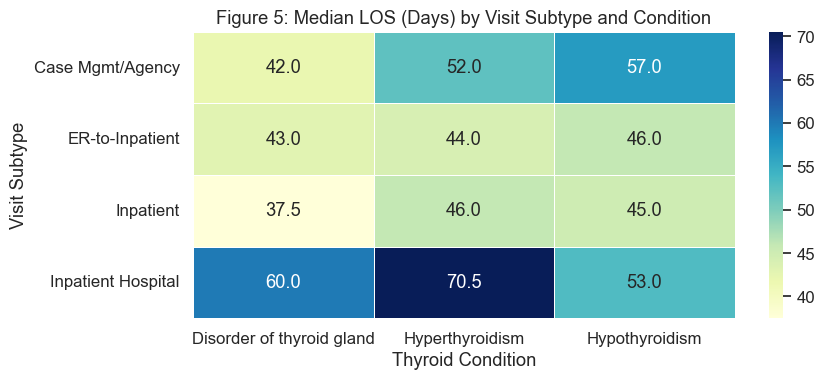

In [ ]:
# Figure 5: Heatmap of Median LOS by Visit Subtype x Condition
# A heatmap shows the interaction between two categorical variables
# simultaneously.

pivot = inp.pivot_table(
    values="los_days", index="visit_subtype", columns="condition_description_clean",
    aggfunc="median",
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_xlabel("Thyroid Condition")
ax.set_ylabel("Visit Subtype")
ax.set_title("Figure 5: Median LOS (Days) by Visit Subtype and Condition")
plt.tight_layout()
plt.show()

### **Step 5. Statistical Testing**

When comparing LOS across groups, the choice of test depends on how many groups you have and whether your data meets normality assumptions. With two groups, I'd use a t-test (normal distribution) or Mann-Whitney U (non-parametric). With three or more groups, I'd use an ANOVA (normal distribution), the Kruskal-Wallis (non-parametric) test. LOS data are very often not normally distributed due to a small amount of extreme outliers. Non-parametric analysis would account for this and I used the Kruskal-Wallis approach due to this.

In [ ]:
# 5a. Kruskal-Wallis tests across each factor
# Kruskal-Wallis is the non-parametric alternative to one-way ANOVA 
# I used it here because LOS distributions are right-skewed.
# Since this is a large dataset, significance alone should be scrutinized as it may not be clinically relevant.
# This is the curse of big data.

def run_kruskal(data, group_col, outcome="los_days"):
    """Run Kruskal-Wallis H test and return results as a dict."""
    groups = [g[outcome].dropna().values for _, g in data.groupby(group_col, observed=True)]
    # Need at least 2 groups with data
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return {"test": "Kruskal-Wallis", "H-statistic": None, "p-value": None, "n_groups": len(groups)}
    stat, p = stats.kruskal(*groups)
    return {"test": "Kruskal-Wallis", "H-statistic": round(stat, 2), "p-value": round(p, 6), "n_groups": len(groups)}

# Run tests for each factor
test_factors = {
    "Visit Subtype": "visit_subtype",
    "Condition": "condition_description_clean",
    "Gender (F vs M)": "gender_clean",
    "Race": "race_clean",
    "Age Decade": "age_decade",
}

results = []
for label, col in test_factors.items():
    subset = inp.dropna(subset=[col])
    # For gender, limit to F and M only (Other/Unknown has n=1)
    if col == "gender_clean":
        subset = subset[subset["gender_clean"].isin(["F", "M"])]
    res = run_kruskal(subset, col)
    res["Factor"] = label
    results.append(res)

results_df = pd.DataFrame(results)[["Factor", "n_groups", "H-statistic", "p-value"]]
print("Kruskal-Wallis H Test Results:")
print("(Tests whether LOS distributions differ across groups)\n")
display(results_df)

Kruskal-Wallis H Test Results:
(Tests whether LOS distributions differ across groups)



,Factor,n_groups,H-statistic,p-value
0,Visit Subtype,4,45.54,0.000000
1,Condition,3,2.52,0.284063
2,Gender (F vs M),2,0.04,0.837543
3,Race,6,2.35,0.799570
4,Age Decade,7,1.85,0.932813


### **Step 6. Narrative: Interpretation and Limitations**

### Methods and Findings

To investigate whether LOS differs by thyroid condition, visit type, gender, race, or age group, we filtered the cleaned thyroid visits dataset to include only visit types where `visit_end_date` is a valid measure of stay duration as noted in the data dictionary. Per the data dictionary, this is only valid for Inpatient Visit, Inpatient Hospital, Emergency Room and Inpatient Visit, and Case Management Agency encounters. This produced a sample of approximately 38,000 visits across roughly 12,500 unique patients. LOS was calculated as the difference in days between `visit_end_date` and `visit_start_date`. Age at visit was derived from `year_of_birth` and the visit start year. This was then grouped into clinical decades (18–29, 30–39, etc.). Descriptive statistics (mean, median, IQR) were computed for each factor, and group differences were tested using the Kruskal-Wallis test because of the non-parametric nature of LOS data.

Across the factors examined, the LOS distributions were notably similar. Median LOS had a narrow range regardless of thyroid condition, visit subtype, gender, race, or age group. While visit subtype reached statistical significance on the Kruskal-Wallis test, the practical difference in median LOS across subtypes was minimal. When looking at the actual LOS values, they ranged from 37.5 to 70.5 days across visit subtypes and thyroid conditions. Inpatient Hospital encounters had notably longer median stays than other visit subtypes, with the longest stay observed in Inpatient Hospital visits for Hyperthyroidism (70.5 days). These values are extraordinarily high for the vast majority of inpatient admissions, much less thyroid-related admissions in real clinical practice. This is almost certainly due to the synthetic nature of the dataset.

### Limitations

Several limitations should be considered when interpreting these results. It should also be noted this is a visit type (admissions, agency) analysis and not a patient level analysis. First, this is a synthetic dataset generated by SubSalt without clinician oversight of the data relationships. Multiple clinically impossible situations were present due to this such as month-long office visits. The uniformity of LOS distributions across distinct visit types (e.g., direct admissions vs ED to inpatient admissions) and across conditions suggests that the synthetic data generation process does not mirror "real world" distributions. Because of this, the absence of group differences should not be interpreted as evidence that these factors do not influence LOS in real-world patients. In actual EHR data, older age, condition severity, and inpatient visit type are established predictors of longer stays.

# **Part 4. Question 3**
## How do the demographic profiles of the thyroid visit cohort compare with the demographic profiles of patients who received TSH, T3, or T4 testing, and do these patterns align with expected real-world thyroid care trends?

### **Step 1: Loading and Preparing the Cohorts**
We import the required libraries and load the cleaned datasets, ensuring the diagnosed cohort is deduplicated by person_id to focus on patient-level rather than visit-level analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the cleaned data
df_diag = pd.read_csv('visits_analysis_ready.csv')
df_test = pd.read_csv('thyroid_testing_cohort.csv')

# Identify unique patients (Deduplication)
# 'thyroid_visit' represents the diagnosed population
# 'testing' represents the cohort that received lab tests
thyroid_visit = df_diag.drop_duplicates(subset='person_id').copy()
testing = df_test.copy()

print(f"Unique diagnosed patients: {len(thyroid_visit)}")
print(f"Unique tested patients: {len(testing)}")

Unique diagnosed patients: 32231
Unique tested patients: 42300


### **Step 2: Standardizing Categorical Variables**
To resolve discrepancies between clinical and laboratory systems (e.g., "Other" vs. "Unknown"), we apply harmonization functions to align gender, race, and ethnicity labels for an accurate comparison.

In [ ]:
# Functions to harmonize categories between clinical and lab data
def harmonize_race(s):
    s = s.fillna("Unknown")
    mapping = {
        "White": "White",
        "Black or African American": "Black",
        "Asian": "Asian",
        "American Indian or Alaska Native": "AIAN",
        "Native Hawaiian or Other Pacific Islander": "NHPI",
        "Other": "Other/Unknown",
        "Unknown": "Other/Unknown"
    }
    return s.map(mapping).fillna("Other/Unknown")

def harmonize_ethnicity(s):
    s = s.fillna("Unknown")
    mapping = {
        "Not Hispanic or Latino": "Not Hispanic",
        "Hispanic or Latino": "Hispanic",
        "Other": "Other/Unknown",
        "Unknown": "Other/Unknown"
    }
    return s.map(mapping).fillna("Other/Unknown")

def harmonize_gender(s):
    s = s.fillna("Other/Unknown")
    return s.replace({"F": "Female", "M": "Male"}).where(lambda x: x.isin(["Female", "Male"]), "Other/Unknown")

# Apply harmonization
thyroid_visit["gender_grp"] = harmonize_gender(thyroid_visit["gender_clean"])
testing["gender_grp"] = harmonize_gender(testing["gender_clean"])

thyroid_visit["race_grp"] = harmonize_race(thyroid_visit["race_clean"])
testing["race_grp"] = harmonize_race(testing["race_clean"])

thyroid_visit["ethnicity_grp"] = harmonize_ethnicity(thyroid_visit["ethnicity_clean"])
testing["ethnicity_grp"] = harmonize_ethnicity(testing["ethnicity_clean"])

# Ensure age groups are handled consistently
thyroid_visit["age_group_cmp"] = thyroid_visit["age_group"].fillna("Missing")
testing["age_group_cmp"] = testing["age_group"].fillna("Missing") 

### **Step 3: Creating the Visualization and Testing Framework**

We define a unified function to generate comparative bar plots and perform Chi-square tests of independence, allowing us to statistically evaluate distribution differences between the two cohorts.

In [ ]:
def run_distribution_analysis(df_diag, df_test, column, title):
    # 1. Create Contingency Table for Chi-square Test (using raw counts)
    diag_counts = df_diag[column].value_counts()
    test_counts = df_test[column].value_counts()
    
    # Combine counts into a single dataframe for the test
    contingency_table = pd.DataFrame({'Diagnosed': diag_counts, 'Tested': test_counts}).fillna(0)
    
    # Run Chi-square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # 2. Calculate Percentages for Visualization
    comparison_pct = (contingency_table / contingency_table.sum() * 100)
    
    # 3. Visualization
    ax = comparison_pct.plot(kind='bar', figsize=(10, 5), width=0.8, color=['#4C72B0', '#DD8452'])
    plt.title(f'Cohort Comparison by {title}', fontsize=14)
    plt.ylabel('Percentage within Cohort (%)')
    plt.xlabel(title)
    plt.xticks(rotation=45, ha='right') # Fix overlapping labels
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # 4. Display Results
    print(f"--- Statistics for {title} ---")
    print(f"Chi-square p-value: {p:.4e}")
    if p < 0.05:
        print("Result: Statistically significant difference in distributions.")
    else:
        print("Result: No statistically significant difference observed.")
    display(comparison_pct.round(2))
    print("\n" + "="*50 + "\n")

### **Step 4: Executing Multi-Variable Profile Analysis**
We run the distribution analysis across gender, age, race, and ethnicity, including a targeted sub-analysis for the female cohort to address the specific clinical trends identified in our research question.

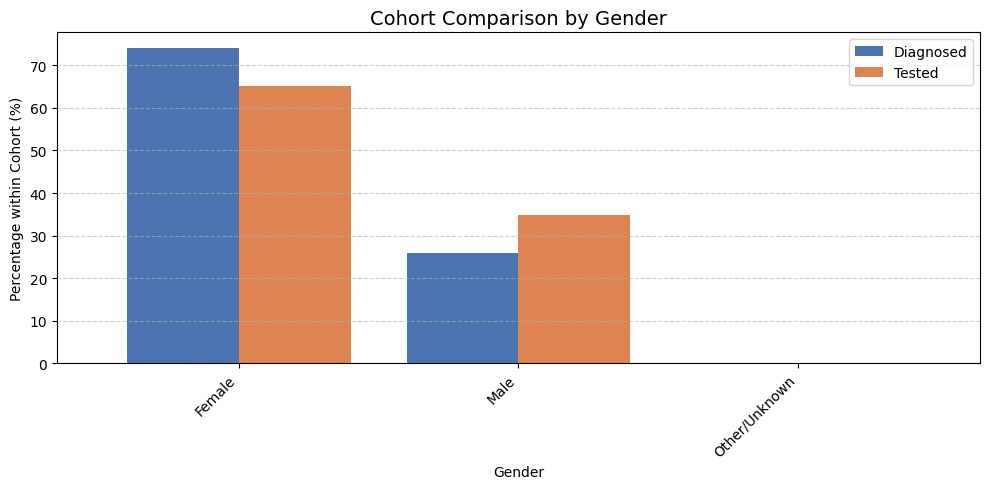

--- Statistics for Gender ---
Chi-square p-value: 5.7494e-149
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
gender_grp,,
Female,74.07,65.24
Male,25.90,34.76
Other/Unknown,0.03,0.00


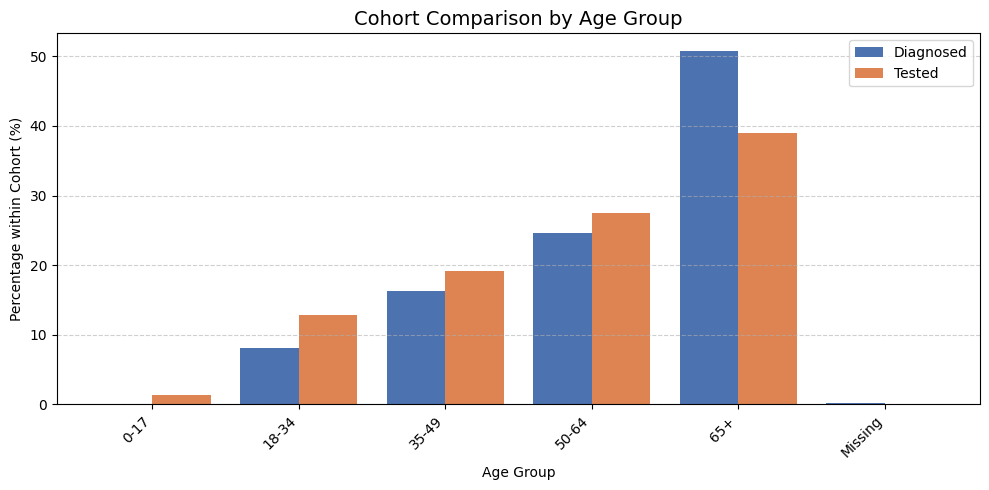

--- Statistics for Age Group ---
Chi-square p-value: 0.0000e+00
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
age_group_cmp,,
0-17,0.00,1.38
18-34,8.05,12.88
35-49,16.24,19.18
50-64,24.68,27.51
65+,50.76,38.98
Missing,0.26,0.07


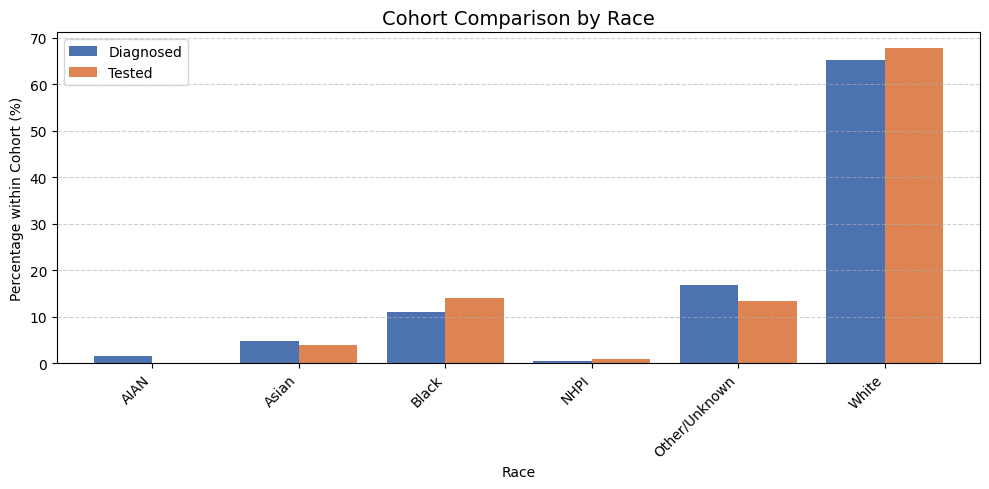

--- Statistics for Race ---
Chi-square p-value: 1.4887e-209
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
race_grp,,
AIAN,1.59,0.06
Asian,4.86,3.91
Black,11.07,14.06
NHPI,0.42,0.88
Other/Unknown,16.83,13.31
White,65.24,67.78


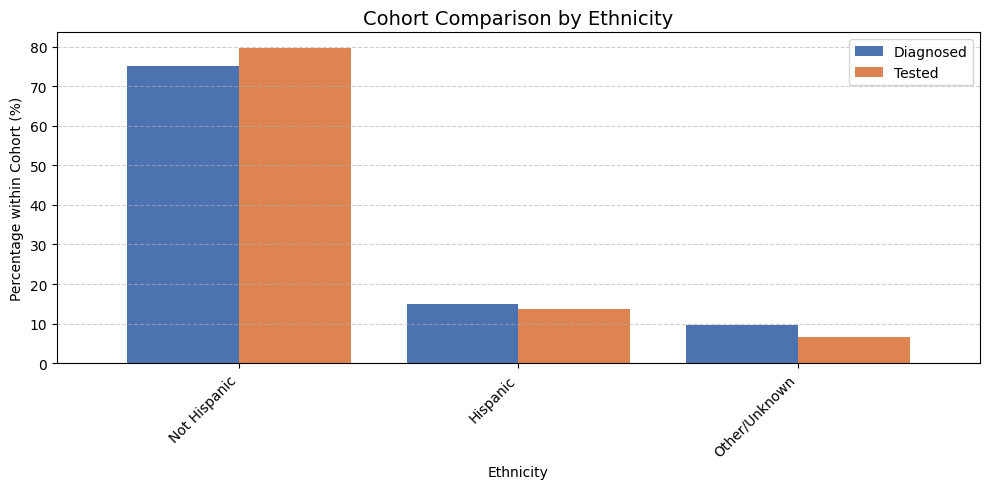

--- Statistics for Ethnicity ---
Chi-square p-value: 1.8977e-63
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
ethnicity_grp,,
Not Hispanic,75.21,79.64
Hispanic,15.03,13.70
Other/Unknown,9.76,6.65


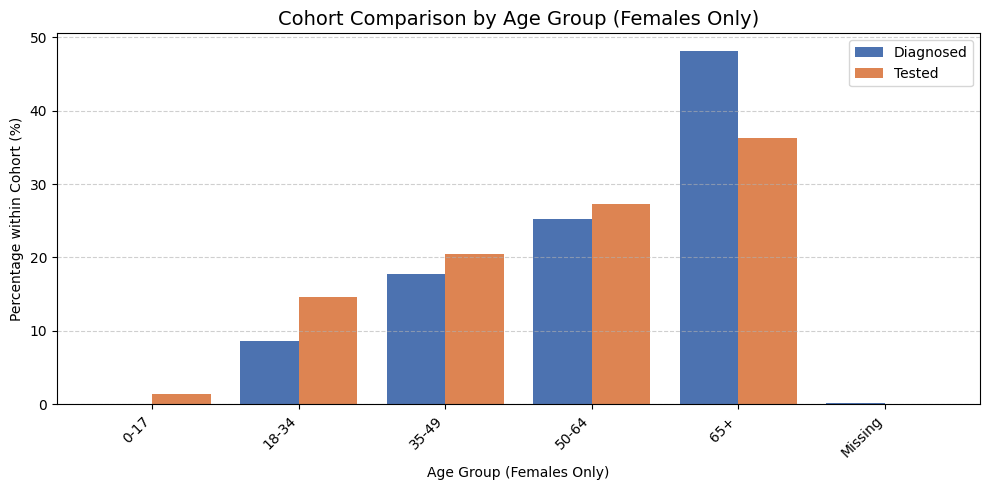

--- Statistics for Age Group (Females Only) ---
Chi-square p-value: 3.6330e-265
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
age_group_cmp,,
0-17,0.00,1.40
18-34,8.68,14.62
35-49,17.78,20.45
50-64,25.17,27.23
65+,48.12,36.23
Missing,0.24,0.07


In [ ]:
# Execute analysis for each demographic profile
run_distribution_analysis(thyroid_visit, testing, 'gender_grp', 'Gender')
run_distribution_analysis(thyroid_visit, testing, 'age_group_cmp', 'Age Group')
run_distribution_analysis(thyroid_visit, testing, 'race_grp', 'Race')
run_distribution_analysis(thyroid_visit, testing, 'ethnicity_grp', 'Ethnicity')

# Sub-analysis: Age distribution within Females only
female_diag = thyroid_visit[thyroid_visit['gender_grp'] == 'Female']
female_test = testing[testing['gender_grp'] == 'Female']
run_distribution_analysis(female_diag, female_test, 'age_group_cmp', 'Age Group (Females Only)')

### **Narrative: Demographic Comparison of Thyroid Cohorts**

### 1. Statistical Overview
A Chi-square test for independence was conducted for all demographic variables to evaluate the relationship between the **Diagnosed cohort** and the **Testing cohort**. All tests yielded a p-value of **$p < 0.001$**, indicating that the distribution of patients significantly differs between the two cohorts across all categories.

* **Diagnosed Cohort (Visits):** 32,231 unique patients.
* **Testing Cohort (Labs):** 42,300 unique patients.

### 2. Key Findings

#### **Gender**
* **Finding:** Females represent **74.1%** of the diagnosed population, which is **directionally consistent** with the higher clinical burden of thyroid disease typically observed in women.
* **Observation:** In the testing cohort, however, the share of females is lower at **65.2%**. While the data reflects the expected higher risk for women, there is a visible **discrepancy** where the testing frequency for females does not fully mirror their diagnostic prevalence compared to the male population.

#### **Age**
* **Trend Alignment:** The data supports the clinical expectation that thyroid risk increases with age. The **35–64 age group** shows proactive screening, with testing rates (**46.7%**) closely aligned with or slightly exceeding diagnosis rates (**41.0%**).
* **The 65+ Gap:** The **65+ group** is the largest diagnosed segment, accounting for **50.8%** of all diagnoses. In contrast, they represent only **39.0%** of the testing cohort. This indicates a significant **mismatch** between the high disease burden in the elderly and the current allocation of diagnostic testing resources.

#### **Race & Ethnicity**
* **Data Harmonization:** Categories for "Other" and "Unknown" were merged into a single group to resolve coding discrepancies between clinical (visit) and laboratory (measurement) systems.
* **Critical Disparity:** While the White population is well-represented in both cohorts (~65–68%), a **notable disparity** was observed for the **American Indian/Alaska Native (AIAN)** group. This group accounts for **1.59%** of diagnoses but only **0.06%** of tests, suggesting a potential barrier to diagnostic access.
* **Ethnicity:** Hispanic patients represent **15.0%** of diagnoses but only **13.7%** of tests ($p < 0.001$), showing a slight under-representation in the testing cohort relative to their disease prevalence.

### 3. Conclusion
The analysis confirms that the study cohorts **reflect real-world clinical trends**, particularly the high prevalence of thyroid conditions in women and the increased risk associated with aging. 

However, the statistical results highlight a **mismatch between clinical risk and resource allocation**. Specifically, the data reveals a **divergence in screening** for the 65+ age group and certain minority populations (notably AIAN). These findings suggest an opportunity to optimize testing strategies to ensure that diagnostic resources are more closely aligned with high-risk patient profiles identified in clinical visits. 

### 4. Limitations

First, it compares two separate extracted cohorts rather than following the same patients from thyroid testing to thyroid diagnosis, so it cannot determine whether any group is under-tested or experiences delayed diagnosis. Second, although demographic categories were harmonized, some remaining coding differences across the visit and laboratory datasets may still affect comparisons, especially for smaller race and ethnicity groups. Third, the analysis is descriptive and based on demographic composition only, without adjustment for clinical factors such as symptoms, comorbidities, provider specialty, or reason for testing. Finally, the notebook compares the thyroid visit cohort with the overall thyroid testing cohort, but separate subgroup analyses for TSH, T3, and T4 testing would further answer the analytic question.
